In [213]:
import numpy as np
import matplotlib.pyplot as plt

## Questão 01 

In [214]:
artificial = np.genfromtxt('./artificial1d.csv', delimiter=',')
artificial

array([[-1.        , -2.08201726],
       [-0.93103448, -1.32698023],
       [-0.86206897, -1.10559772],
       [-0.79310345, -0.87394576],
       [-0.72413793, -0.28502695],
       [-0.65517241, -0.43115252],
       [-0.5862069 , -0.79475402],
       [-0.51724138, -0.88606806],
       [-0.44827586, -0.89989978],
       [-0.37931034, -0.86184365],
       [-0.31034483, -0.88805183],
       [-0.24137931, -1.23595129],
       [-0.17241379, -0.71956827],
       [-0.10344828, -0.45202286],
       [-0.03448276,  0.09889951],
       [ 0.03448276,  0.34896973],
       [ 0.10344828,  0.09747797],
       [ 0.17241379,  0.70019809],
       [ 0.24137931,  1.31051213],
       [ 0.31034483,  1.00177576],
       [ 0.37931034,  1.00318231],
       [ 0.44827586,  1.14910129],
       [ 0.51724138,  1.59220607],
       [ 0.5862069 ,  0.60909009],
       [ 0.65517241,  0.59441623],
       [ 0.72413793,  0.70300732],
       [ 0.79310345,  0.82332241],
       [ 0.86206897,  1.10646439],
       [ 0.93103448,

### a) OLS

In [215]:
def calc_mse(y_original, y_previsto):
    return float(np.mean((y_original - y_previsto)**2))

Parâmetros do modelo: w0: [0.06761792] | w1: [1.57486517]
O modelo OLS registrou um MSE de: 0.21340090132936987


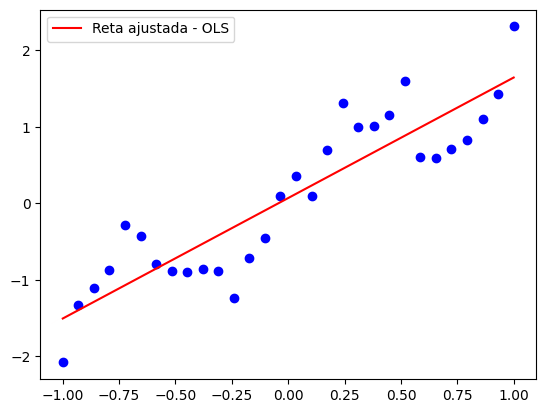

In [216]:
n = np.shape(artificial)[0]
x = artificial[:,[0]] # coluna x
X = np.concatenate((np.ones((1,n)).T , artificial[:,[0]]), axis=1) # X
y = artificial[:,[1]]

inv = np.linalg.inv(X.T @ X) # inversa de X
w = inv @ X.T @ y
y_previsto = X @ w

mse = calc_mse(y, y_previsto)
print(f"Parâmetros do modelo: w0: {w[0]} | w1: {w[1]}")
print(f"O modelo OLS registrou um MSE de: {mse}")

plt.scatter(x, y, color='blue')
plt.plot(x, y_previsto, color='red', label='Reta ajustada - OLS')
plt.legend(loc="upper left")
plt.show()

### b) GD

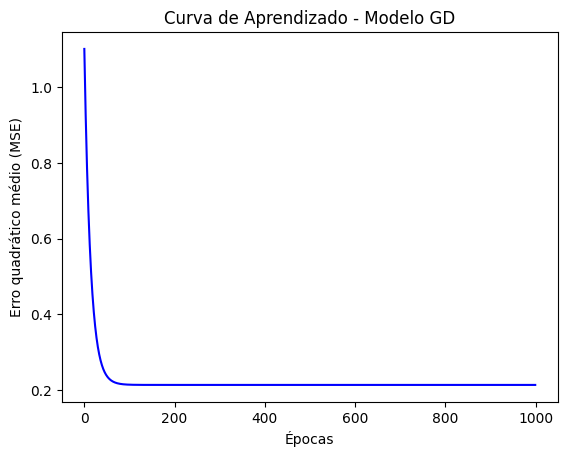

Parâmetros do modelo: w0:[0.06761792] | w1: [1.57486517]
O modelo GD registrou um MSE de: 0.2134009013293699


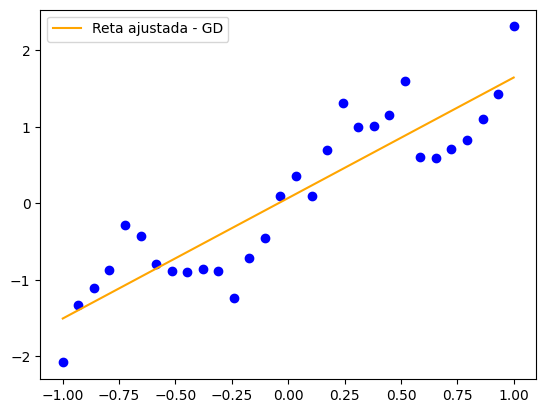

In [217]:
alfa = 0.1
n = artificial.shape[0]
epocas = 1000

X = np.concatenate((np.ones((1,n)).T , artificial[:,[0]]), axis=1) 
y = artificial[:,[1]]
w = np.zeros((X.shape[1], 1))

custo = []

for epoca in range(epocas):
    y_est = X @ w
    ei = y - y_est
    w = w + alfa * (X.T @ ei)/n 

    mse = np.mean(ei**2)
    custo.append(mse)

# plot - curva de aprendizado
plt.figure()
plt.plot(custo, color='blue')
plt.title('Curva de Aprendizado - Modelo GD')
plt.xlabel('Épocas')
plt.ylabel('Erro quadrático médio (MSE)')
plt.show()

y_final = X @ w 
mse = calc_mse(y, y_final)

print(f"Parâmetros do modelo: w0:{w[0]} | w1: {w[1]}")
print(f"O modelo GD registrou um MSE de: {mse}")

# plot reta
plt.figure()
plt.scatter(x, y, color='blue')
plt.plot(x, y_final, label='Reta ajustada - GD', color='orange')
plt.legend(loc='upper left')
plt.show()

### c) SGD

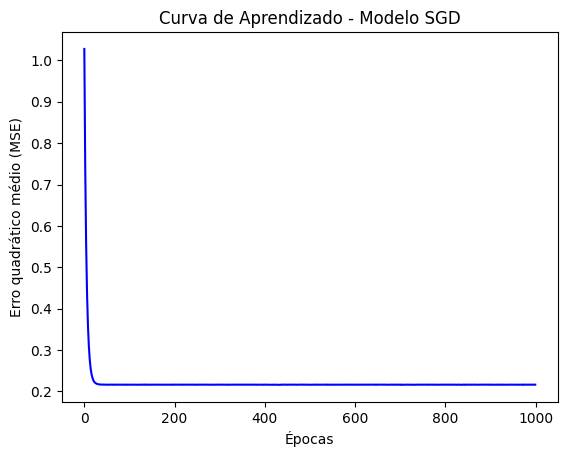

Parâmetros do modelo: w0:[0.06431143] | w1: [1.57563909]
O modelo SGD registrou um MSE de: 0.2134120476851011


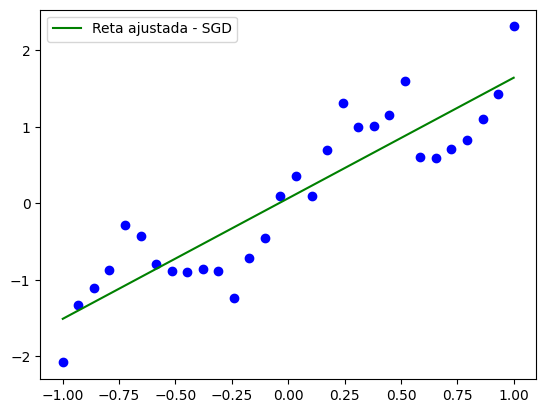

In [218]:
alfa = 10**(-2)
n = artificial.shape[0]
epocas = 1000

X = np.concatenate((np.ones((1,n)).T , artificial[:,[0]]), axis=1) 
y = artificial[:,[1]]
w = np.zeros((X.shape[1], 1))

mse_hist = []

for epoca in range(epocas):
    indices = np.random.permutation(n)
    X_perm = X[indices]
    y_perm = y[indices]
    erros_epoca = []
    
    for i in range(n):
        xi = X_perm[i].reshape(-1, 1)
        yi = y_perm[i].reshape(-1, 1)

        y_est = w.T @ xi
        ei = yi - y_est

        w = w + alfa * ei * xi
        erros_epoca.append(ei**2)
    
    mse = np.mean(erros_epoca)
    mse_hist.append(mse)
        

# plot - curva de aprendizado
plt.figure()
plt.plot(mse_hist, color='blue')
plt.title('Curva de Aprendizado - Modelo SGD')
plt.xlabel('Épocas')
plt.ylabel('Erro quadrático médio (MSE)')
plt.show()

y_final = X @ w 
mse = calc_mse(y, y_final)

print(f"Parâmetros do modelo: w0:{w[0]} | w1: {w[1]}")
print(f"O modelo SGD registrou um MSE de: {mse}")

plt.figure()
plt.scatter(x, y, color='blue')
plt.plot(x, y_final, label='Reta ajustada - SGD', color='green')
plt.legend(loc='upper left')
plt.show()

## Questão 02


In [219]:
california = np.genfromtxt('./california.csv', delimiter=',')

### a)  Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%)

In [220]:
x = california[:, 0:8] # dados | pegando as 8 primeiras colunas
y = california[:, [8]]

indices = np.random.permutation(len(x))
x = x[indices]
y = y[indices]

tam_treino = int(0.8 * len(x))

x_treino = x[:tam_treino]
x_teste = x[tam_treino:]
y_treino = y[:tam_treino]
y_teste = y[tam_treino:]

# normalizando
mi_x = np.mean(x_treino, axis=0)
sigma_x = np.std(x_treino, axis=0, ddof=1)

# conjunto de treino normalizado (x usando StandardScaler ; y usando MinMax)
x_treino_norm = (x_treino - mi_x)/sigma_x
y_treino_norm = ((y_treino - y_treino.min(axis=0))/(y_treino.max(axis=0) - y_treino.min(axis=0)))

# conjunto de teste normalizado (x usando StandardScaler ; y usando MinMax)
x_teste_norm = (x_teste - mi_x)/sigma_x
y_teste_norm = ((y_teste - y_treino.min(axis=0))/(y_treino.max(axis=0) - y_treino.min(axis=0)))

Polinômio de grau 1 | RMSE do treino: 0.6684894494460607 | RMSE do teste: 0.6937167205390404
Polinômio de grau 2 | RMSE do treino: 1.0128685984717694 | RMSE do teste: 1.0109822380817872
Polinômio de grau 3 | RMSE do treino: 0.9781901282937946 | RMSE do teste: 1.2096669104177684
Polinômio de grau 4 | RMSE do treino: 1.0738282096780396 | RMSE do teste: 1.2443731860251837
Polinômio de grau 5 | RMSE do treino: 1.0787400318748472 | RMSE do teste: 3.445723556751345
Polinômio de grau 6 | RMSE do treino: 1.1047724124448093 | RMSE do teste: 2.581707661999587
Polinômio de grau 7 | RMSE do treino: 1.109100008651474 | RMSE do teste: 11.963072289509071
Polinômio de grau 8 | RMSE do treino: 1.1167255354051315 | RMSE do teste: 7.653347969375944
Polinômio de grau 9 | RMSE do treino: 1.1212855975574922 | RMSE do teste: 41.116599933975436
Polinômio de grau 10 | RMSE do treino: 1.1232594106645817 | RMSE do teste: 25.624526868564306
Polinômio de grau 11 | RMSE do treino: 1.1280863383155386 | RMSE do teste

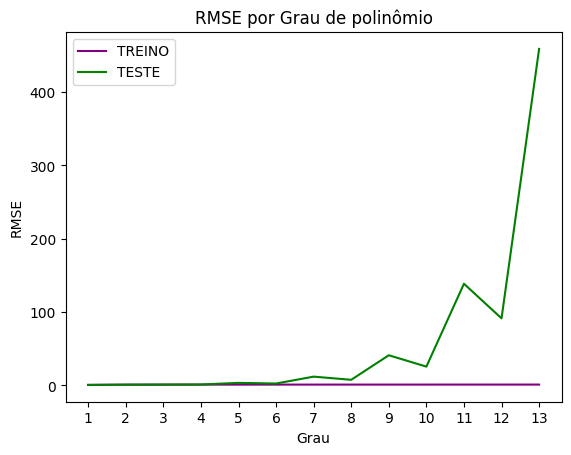

In [223]:
rmse_treino = []
rmse_teste = []

for p in range(1, 14):
    
    for i in range(1, p+1):
        x_treino = np.concatenate([np.ones((len(x_treino_norm), 1)), x_treino_norm**i], axis=1)
        x_teste = np.concatenate([np.ones((len(x_teste_norm),1)), x_teste_norm**i], axis=1)
        
    w = np.linalg.inv(x_treino.T @ x_treino) @ x_treino.T @ y_treino_norm
    
    # print(f"Parâmetros para polinômio de grau {p}")
    # for i in range(len(w)):
    #     print(f'w{i}: {w[i]}')
    
    y_previsto_treino = x_treino @ w
    
    # desnormalizando TREINO para calcular rmse
    y_previsto_treino_desnorm = y_previsto_treino * (y_treino.max(axis=0) - y_treino.min(axis=0)) + y_treino.min(axis=0)
    rmse_tr = np.sqrt(np.mean((y_previsto_treino_desnorm - y_treino) ** 2))
    
    rmse_treino.append(rmse_tr)
    
    y_previsto_teste = x_teste @ w
    
    # desnormalizando TESTE para calcular rmse
    y_previsto_teste_desnorm = y_previsto_teste * (y_treino.max(axis=0) - y_treino.min(axis=0)) + y_treino.min(axis=0)
    rmse_tst = np.sqrt(np.mean((y_previsto_teste_desnorm - y_teste) ** 2))
    
    rmse_teste.append(rmse_tst)
    
    print(f"Polinômio de grau {p} | RMSE do treino: {rmse_tr} | RMSE do teste: {rmse_tst}") 
    
plt.figure()
plt.plot(range(1, 14), rmse_treino, label='TREINO', color='purple')   
plt.plot(range(1, 14), rmse_teste, label='TESTE', color='green')
plt.title("RMSE por Grau de polinômio")
plt.xlabel("Grau")
plt.xticks(range(1, 14))
plt.ylabel("RMSE")
plt.legend(loc='upper left')
plt.show()

Polinômio de grau 1 | RMSE do treino: 0.668489452889197 | RMSE do teste: 0.6937095242955883
Polinômio de grau 2 | RMSE do treino: 1.0128685985522101 | RMSE do teste: 1.0109800301843839
Polinômio de grau 3 | RMSE do treino: 0.9781901283026663 | RMSE do teste: 1.209666778795173
Polinômio de grau 4 | RMSE do treino: 1.0738282096781235 | RMSE do teste: 1.244373346370159
Polinômio de grau 5 | RMSE do treino: 1.0787400318748528 | RMSE do teste: 3.445723374690201
Polinômio de grau 6 | RMSE do treino: 1.1047724124448095 | RMSE do teste: 2.5817078172482493
Polinômio de grau 7 | RMSE do treino: 1.109100008651474 | RMSE do teste: 11.963072193775572
Polinômio de grau 8 | RMSE do treino: 1.1167255354051315 | RMSE do teste: 7.653348024654579
Polinômio de grau 9 | RMSE do treino: 1.1212855975574922 | RMSE do teste: 41.11659990352536
Polinômio de grau 10 | RMSE do treino: 1.1232594106645817 | RMSE do teste: 25.624526884512296
Polinômio de grau 11 | RMSE do treino: 1.1280863383155388 | RMSE do teste: 1

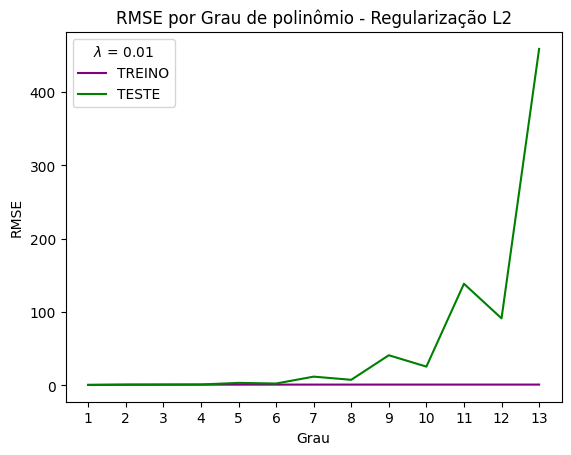

In [225]:
# treinamento com regularização

rmse_treino = []
rmse_teste = []
lamb = 0.01

for p in range(1, 14):
    
    for i in range(1, p+1):
        x_treino = np.concatenate([np.ones((len(x_treino_norm), 1)), x_treino_norm**i], axis=1)
        x_teste = np.concatenate([np.ones((len(x_teste_norm),1)), x_teste_norm**i], axis=1)
    
    I = np.eye(x_treino.shape[1])
    I[0,0] = 0 # w0 não é regularizado
    w = np.linalg.inv(x_treino.T @ x_treino + lamb*I) @ x_treino.T @ y_treino_norm
    
    # print(f"Parâmetros para polinômio de grau {p}")
    # for i in range(len(w)):
    #     print(f'w{i}: {w[i]}')
    
    y_previsto_treino = x_treino @ w
    
    # desnormalizando TREINO para calcular rmse
    y_previsto_treino_desnorm = y_previsto_treino * (y_treino.max(axis=0) - y_treino.min(axis=0)) + y_treino.min(axis=0)
    rmse_tr = np.sqrt(np.mean((y_previsto_treino_desnorm - y_treino) ** 2))
    
    rmse_treino.append(rmse_tr)
    
    y_previsto_teste = x_teste @ w
    
    # desnormalizando TESTE para calcular rmse
    y_previsto_teste_desnorm = y_previsto_teste * (y_treino.max(axis=0) - y_treino.min(axis=0)) + y_treino.min(axis=0)
    rmse_tst = np.sqrt(np.mean((y_previsto_teste_desnorm - y_teste) ** 2))
    
    rmse_teste.append(rmse_tst)
    
    print(f"Polinômio de grau {p} | RMSE do treino: {rmse_tr} | RMSE do teste: {rmse_tst}") 
    
plt.figure()
plt.plot(range(1, 14), rmse_treino, label='TREINO', color='purple')   
plt.plot(range(1, 14), rmse_teste, label='TESTE', color='green')
plt.title("RMSE por Grau de polinômio - Regularização L2")
plt.xlabel("Grau")
plt.xticks(range(1, 14))
plt.ylabel("RMSE")
plt.legend(title=rf"$\lambda$ = {lamb}", loc='upper left')
plt.show()